In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv('data/heart.csv')

In [6]:
#df.head()
df.info()
df.describe()
#df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 97.6 KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,243.204793,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.990127,53.401297,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
mean_val = df['MaxHR'].mean()
std_val = df['MaxHR'].std()
cv = std_val/mean_val

In [8]:
print(round(cv,3))

0.186


In [2]:
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())
df['RestingBP'] = df['RestingBP'].replace(0,np.nan)
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())

In [3]:
print((df['Cholesterol']==0).sum())

0


In [13]:
#df['Sex'].value_counts()
#df['ChestPainType'].value_counts()
#df['RestingECG'].value_counts()
df['ExerciseAngina'].value_counts()
#f['ST_Slope'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

<Axes: >

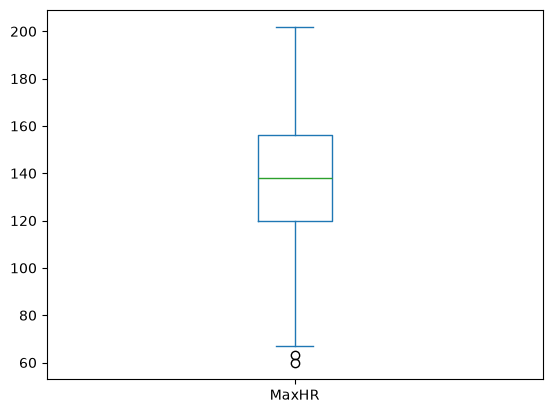

In [14]:
df['MaxHR'].plot(kind='box')

In [15]:
df[df['MaxHR']<66]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
370,60,M,ASY,135.0,237.0,0,Normal,63,Y,0.5,Up,1
390,51,M,ASY,140.0,237.0,0,Normal,60,N,0.0,Flat,1


In [16]:
df['Sex'] = df['Sex'].map({'M':0,'F':1})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'N':0,'Y':1})

In [17]:
df = pd.get_dummies(df,columns=['ChestPainType','RestingECG','ST_Slope'],drop_first=True)


In [19]:
from sklearn.model_selection import train_test_split

X = df.drop(['HeartDisease'],axis=1)
y = df['HeartDisease']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [22]:
log_model = LogisticRegression()

In [23]:
log_model.fit(X_train_scaled,y_train)
log_predictions = log_model.predict(X_test_scaled)

In [27]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_predictions))
print("Precision:", precision_score(y_test, log_predictions))
print("Recall:", recall_score(y_test, log_predictions))
print("F1 Score:", f1_score(y_test, log_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_predictions))

Logistic Regression
Accuracy: 0.8586956521739131
Precision: 0.9090909090909091
Recall: 0.8411214953271028
F1 Score: 0.8737864077669902
Confusion Matrix:
 [[68  9]
 [17 90]]


In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
decision_model = DecisionTreeClassifier(random_state=42)
decision_model.fit(X_train_scaled,y_train)
decision_predictions = decision_model.predict(X_test_scaled)

In [31]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, decision_predictions))
print("Precision:", precision_score(y_test, decision_predictions))
print("Recall:", recall_score(y_test, decision_predictions))
print("F1 Score:", f1_score(y_test, decision_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, decision_predictions))

Decision Tree
Accuracy: 0.8097826086956522
Precision: 0.86
Recall: 0.8037383177570093
F1 Score: 0.8309178743961353
Confusion Matrix:
 [[63 14]
 [21 86]]


In [32]:
for depth in [3, 4, 5, 6]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_acc = dt.score(X_train_scaled, y_train)
    test_acc = dt.score(X_test_scaled, y_test)
    print(f"max_depth={depth} → Train: {train_acc:.3f}, Test: {test_acc:.3f}")

max_depth=3 → Train: 0.851, Test: 0.799
max_depth=4 → Train: 0.872, Test: 0.826
max_depth=5 → Train: 0.887, Test: 0.815
max_depth=6 → Train: 0.906, Test: 0.804


In [34]:
best_depth = 4  # whichever depth the loop showed as best

dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_final.fit(X_train_scaled, y_train)
dt_final_predictions = dt_final.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, dt_final_predictions))
print("Precision:", precision_score(y_test, dt_final_predictions))
print("Recall:", recall_score(y_test, dt_final_predictions))
print("F1 Score:", f1_score(y_test, dt_final_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_final_predictions))

Accuracy: 0.8260869565217391
Precision: 0.8947368421052632
Recall: 0.794392523364486
F1 Score: 0.8415841584158416
Confusion Matrix:
 [[67 10]
 [22 85]]


In [35]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier(random_state=42)
rfc_model.fit(X_train_scaled,y_train)
rfc_predictions = rfc_model.predict(X_test_scaled)

In [36]:
print("Accuracy:", accuracy_score(y_test, rfc_predictions))
print("Precision:", precision_score(y_test, rfc_predictions))
print("Recall:", recall_score(y_test, rfc_predictions))
print("F1 Score:", f1_score(y_test, rfc_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, rfc_predictions))

Accuracy: 0.8641304347826086
Precision: 0.8867924528301887
Recall: 0.8785046728971962
F1 Score: 0.8826291079812206
Confusion Matrix:
 [[65 12]
 [13 94]]


In [37]:
from sklearn.neighbors import KNeighborsClassifier
knc_model = KNeighborsClassifier()
knc_model.fit(X_train_scaled,y_train)
knc_predictions = knc_model.predict(X_test_scaled)

In [38]:
print("Accuracy:", accuracy_score(y_test, knc_predictions))
print("Precision:", precision_score(y_test, knc_predictions))
print("Recall:", recall_score(y_test, knc_predictions))
print("F1 Score:", f1_score(y_test, knc_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, knc_predictions))

Accuracy: 0.8478260869565217
Precision: 0.8910891089108911
Recall: 0.8411214953271028
F1 Score: 0.8653846153846154
Confusion Matrix:
 [[66 11]
 [17 90]]


In [ ]:
from sklearn.svm import SVC
svc_model = SVC()
svc_model.fit(X_train_scaled,y_train)
svc_predictions = svc_model.predict(X_test_scaled)

In [43]:
print("Accuracy:", accuracy_score(y_test, svc_predictions))
print("Precision:", precision_score(y_test, svc_predictions))
print("Recall:", recall_score(y_test, svc_predictions))
print("F1 Score:", f1_score(y_test, svc_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, svc_predictions))

Accuracy: 0.8586956521739131
Precision: 0.8932038834951457
Recall: 0.8598130841121495
F1 Score: 0.8761904761904762
Confusion Matrix:
 [[66 11]
 [15 92]]


In [44]:
from sklearn.naive_bayes import GaussianNB
naive_model = GaussianNB()
naive_model.fit(X_train_scaled,y_train)
naive_predictions = naive_model.predict(X_test_scaled)

In [45]:
print("Accuracy:", accuracy_score(y_test, naive_predictions))
print("Precision:", precision_score(y_test, naive_predictions))
print("Recall:", recall_score(y_test, naive_predictions))
print("F1 Score:", f1_score(y_test, naive_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, naive_predictions))

Accuracy: 0.8478260869565217
Precision: 0.9157894736842105
Recall: 0.8130841121495327
F1 Score: 0.8613861386138614
Confusion Matrix:
 [[69  8]
 [20 87]]


In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_scaled,y_train)
xgb_predictions = xgb_model.predict(X_test_scaled)


{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [47]:
print("Accuracy:", accuracy_score(y_test, xgb_predictions))
print("Precision:", precision_score(y_test, xgb_predictions))
print("Recall:", recall_score(y_test, xgb_predictions))
print("F1 Score:", f1_score(y_test, xgb_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_predictions))

Accuracy: 0.842391304347826
Precision: 0.875
Recall: 0.8504672897196262
F1 Score: 0.8625592417061612
Confusion Matrix:
 [[64 13]
 [16 91]]


In [48]:
import joblib
joblib.dump(rfc_model, 'heart_random_forest_model.pkl')
joblib.dump(scaler,'heart_scaler.pkl')

['heart_scaler.pkl']